LangChain helps us communicate with LLMs


In [ ]:
!pip install -q langchain langchain-groq python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.3 MB/s eta 0:00:00


In [ ]:
from langchain_groq import ChatGroq

In [ ]:
GROQ_API_KEY = ""

In [ ]:
llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

In [ ]:
def generate_post(topic):
    prompt = f"""
You are an expert Social Media Manager.

Create a professional LinkedIn post for the topic: {topic}

Also include:
1. A catchy title
2. A professional post
3. 5 relevant hashtags
4. A Call-to-Action (CTA)

Return the output in a clean format.
"""

    response = llm.invoke(prompt)
    return response.content

In [ ]:
topic = input("Enter your topic: ")

Enter your topic: Artificial Intelligence in Healthcare


In [ ]:
result = generate_post(topic)

In [ ]:
print(result)

**Revolutionizing Healthcare: The Rise of Artificial Intelligence**

As we continue to navigate the complexities of the healthcare industry, it's becoming increasingly clear that Artificial Intelligence (AI) is playing a vital role in shaping the future of patient care. From diagnostic analytics to personalized treatment plans, AI is transforming the way healthcare professionals approach medicine.

With the ability to process vast amounts of data, AI algorithms can identify patterns and insights that human clinicians may miss, leading to more accurate diagnoses and effective treatments. Additionally, AI-powered chatbots and virtual assistants are improving patient engagement and experience, enabling individuals to take a more proactive role in their healthcare.

As the healthcare landscape continues to evolve, it's essential for professionals to stay informed about the latest AI trends and innovations. Whether you're a healthcare provider, researcher, or industry leader, it's crucial t

In [ ]:
!pip install -q pydantic

In [ ]:
from pydantic import BaseModel

In [ ]:
class SocialMediaPost(BaseModel):
    title: str
    post: str
    hashtags: list[str]
    cta: str

In [ ]:
def generate_post(topic):
    prompt = f"""
You are an expert Social Media Manager.

Generate a LinkedIn post on the topic: {topic}

Return the response in JSON format like this:

{{
"title": "...",
"post": "...",
"hashtags": ["...", "...", "...", "...", "..."],
"cta": "..."
}}
"""

    structured_llm = llm.with_structured_output(SocialMediaPost)

    response = structured_llm.invoke(prompt)

    return response

In [ ]:
topic = input("Enter Topic: ")

result = generate_post(topic)

print("Title:", result.title)
print("\nPost:\n", result.post)
print("\nHashtags:", ", ".join(result.hashtags))
print("\nCTA:", result.cta)

Enter Topic: Future of Generative AI
Title: The Future of Generative AI: Revolutionizing Industries

Post:
 As we step into a new era of technological advancements, generative AI is poised to revolutionize various industries. From creating art and music to generating text and code, the possibilities are endless. But what does the future hold for this technology? Share your thoughts and let's discuss the potential impact of generative AI on our world.

Hashtags: #GenerativeAI, #AIRevolution, #FutureOfTech, #Innovation, #ArtificialIntelligence

CTA: Join the conversation and share your insights in the comments below!


In [ ]:
def rewrite_post(post):
    prompt = f"""
You are an expert Social Media Manager.

Rewrite the following LinkedIn post to make it more engaging and professional.

Post:
{post}
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
choice = input("\nApprove, Reject or Rewrite? ").lower()


Approve, Reject or Rewrite? Approve


In [ ]:
if choice == "approve":
    print("\n✅ Post Approved!")

elif choice == "rewrite":
    new_post = rewrite_post(result.post)

    print("\n🔄 Rewritten Post:\n")
    print(new_post)

elif choice == "reject":
    print("\n❌ Post Rejected!")

else:
    print("\n⚠️ Invalid Choice!")


✅ Post Approved!


In [ ]:
def generate_hashtags(topic):
    prompt = f"""
Generate only 5 trending LinkedIn hashtags for the topic:
{topic}

Return only the hashtags separated by commas.
"""

    response = llm.invoke(prompt)
    return response.content

In [ ]:
def generate_caption(topic):
    prompt = f"""
Generate a short and engaging LinkedIn caption for:
{topic}
"""

    response = llm.invoke(prompt)
    return response.content

In [ ]:
def translate_post(post, language):
    prompt = f"""
Translate the following LinkedIn post into {language}.

Post:
{post}
"""

    response = llm.invoke(prompt)
    return response.content

In [ ]:
print("\nChoose a Tool")
print("1. Generate Post")
print("2. Generate Hashtags")
print("3. Generate Caption")
print("4. Translate Post")

choice = input("Enter your choice (1-4): ")


Choose a Tool
1. Generate Post
2. Generate Hashtags
3. Generate Caption
4. Translate Post
Enter your choice (1-4): 1. Generate Post


In [ ]:
if choice == "1":
    topic = input("Enter Topic: ")
    print(generate_post(topic))

elif choice == "2":
    topic = input("Enter Topic: ")
    print(generate_hashtags(topic))

elif choice == "3":
    topic = input("Enter Topic: ")
    print(generate_caption(topic))

elif choice == "4":
    post = input("Enter the Post: ")
    language = input("Enter Language: ")
    print(translate_post(post, language))

else:
    print("Invalid Choice!")

Invalid Choice!


In [ ]:
def social_media_agent(user_request):

    request = user_request.lower()

    if "hashtag" in request:
        topic = request.replace("hashtags", "").replace("hashtag", "").strip()
        return generate_hashtags(topic)

    elif "caption" in request:
        topic = request.replace("caption", "").strip()
        return generate_caption(topic)

    elif "translate" in request:
        print("Translation feature will be added later.")

    else:
        return generate_post(user_request)

In [ ]:
user_request = input("Ask the AI Agent: ")

result = social_media_agent(user_request)

print("\nAI Agent Response:\n")
print(result)

Ask the AI Agent: Create a LinkedIn post on Artificial Intelligence

AI Agent Response:

title='The Future of Work: How Artificial Intelligence is Revolutionizing Industries' post="Artificial Intelligence (AI) is transforming the way we work and live. From automating routine tasks to enhancing decision-making, AI is revolutionizing industries and creating new opportunities. As we continue to navigate this technological shift, it's essential to stay informed and adapt to the changing landscape. What are your thoughts on the impact of AI on your industry? Share your insights and let's start a conversation!" hashtags=['#ArtificialIntelligence', '#AI', '#FutureOfWork', '#Innovation', '#Technology'] cta="Let's connect and explore the possibilities of AI together!"


In [ ]:
!pip install -q langgraph

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

In [ ]:
class AgentState(TypedDict):
    user_request: str
    result: str

In [ ]:
def ai_node(state):

    request = state["user_request"]

    result = social_media_agent(request)

    return {
        "result": result
    }

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("AI", ai_node)

workflow.set_entry_point("AI")

workflow.set_finish_point("AI")

app = workflow.compile()

In [ ]:
user_request = input("Ask the AI Agent: ")

result = app.invoke({
    "user_request": user_request
})

print("\nResult:\n")
post = result["result"]

print("\n========== AI SOCIAL MEDIA POST ==========\n")

print("📌 Title:")
print(post.title)

print("\n📝 Post:")
print(post.post)

print("\n🏷️ Hashtags:")
print(", ".join(post.hashtags))

print("\n📢 Call To Action:")
print(post.cta)

Ask the AI Agent: Create a LinkedIn post about Artificial Intelligence

Result:


========== AI SOCIAL MEDIA POST ==========

📌 Title:
The Future of Work: How Artificial Intelligence is Revolutionizing Industries

📝 Post:
Artificial Intelligence (AI) is transforming the way we work and live. From automating routine tasks to enhancing decision-making, AI is revolutionizing industries and creating new opportunities. As professionals, it's essential to stay ahead of the curve and understand the impact of AI on our careers and businesses. What are your thoughts on the future of AI? Share your insights and let's start a conversation!

🏷️ Hashtags:
#ArtificialIntelligence, #AI, #FutureOfWork, #Innovation, #Technology

📢 Call To Action:
Let's connect and explore the possibilities of AI together!


In [ ]:
def generate_platform_post(topic, platform):

    prompt = f"""
You are an expert Social Media Manager.

Create a {platform} post on the topic:

{topic}

Rules:

If platform is LinkedIn:
- Professional tone
- 150-200 words
- 5 hashtags
- Call to Action

If platform is Instagram:
- Short caption
- Attractive emojis
- 8 hashtags

If platform is Twitter (X):
- Maximum 280 characters
- 3 hashtags

Return the response in JSON format:

{{
"title":"...",
"post":"...",
"hashtags":["..."],
"cta":"..."
}}
"""

    structured_llm = llm.with_structured_output(SocialMediaPost)

    response = structured_llm.invoke(prompt)

    return response

In [ ]:
platform = input("Choose Platform (LinkedIn / Instagram / Twitter): ")

topic = input("Enter Topic: ")

result = generate_platform_post(topic, platform)

Choose Platform (LinkedIn / Instagram / Twitter): LinkedIn
Enter Topic: Artificial Intelligence in Healthcare


In [ ]:
print("\n========== GENERATED POST ==========\n")

print("Platform:", platform)

print("\n📌 Title:")
print(result.title)

print("\n📝 Post:")
print(result.post)

print("\n🏷️ Hashtags:")
print(", ".join(result.hashtags))

print("\n📢 CTA:")
print(result.cta)


========== GENERATED POST ==========

Platform: LinkedIn

📌 Title:
Revolutionizing Healthcare with AI

📝 Post:
The integration of Artificial Intelligence in healthcare is transforming the industry. From predictive analytics to personalized medicine, AI is improving patient outcomes and streamlining clinical workflows. As we continue to advance in this field, it's exciting to think about the potential for AI to revolutionize healthcare as we know it. With the ability to analyze vast amounts of data, AI can help doctors make more accurate diagnoses and develop targeted treatment plans. This technology has the potential to save countless lives and improve the overall quality of care. As professionals in the healthcare industry, it's essential that we stay up-to-date on the latest developments in AI and explore ways to implement this technology in our own work.

🏷️ Hashtags:
#ArtificialIntelligence, #HealthcareInnovation, #MedicalTechnology, #HealthcareRevolution, #AIinHealthcare

📢 CTA:


In [ ]:
!pip install -q transformers pillow accelerate

In [ ]:
from transformers import pipeline
from PIL import Image
from google.colab import files

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration
import torch

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image = Image.open(image_name)

image.show()

Saving ai.jpg to ai (4).jpg


In [ ]:
inputs = processor(images=image, return_tensors="pt")

output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print("Generated Caption:")
print(caption)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Generated Caption:
artificial intelligence artificial intelligence artificial intelligence artificial intelligence artificial intelligence artificial intelligence artificial intelligence artificial intelligence


In [ ]:
prompt = f"""
You are an expert Social Media Manager.

Based on the following image description:

{caption}

Generate:

1. Title
2. LinkedIn Post
3. 5 Hashtags
4. Call To Action

Return the response in JSON format:

{{
"title":"",
"post":"",
"hashtags":["","","","",""],
"cta":""
}}
"""

structured_llm = llm.with_structured_output(SocialMediaPost)

result = structured_llm.invoke(prompt)

In [ ]:
print("\n========== IMAGE TO SOCIAL MEDIA POST ==========\n")

print("📌 Title:")
print(result.title)

print("\n📝 LinkedIn Post:")
print(result.post)

print("\n🏷️ Hashtags:")
print(", ".join(result.hashtags))

print("\n📢 CTA:")
print(result.cta)


========== IMAGE TO SOCIAL MEDIA POST ==========

📌 Title:
The Future is Here: Embracing Artificial Intelligence

📝 LinkedIn Post:
Artificial intelligence is revolutionizing the way we live and work. From automating tasks to enhancing decision-making, AI is transforming industries and creating new opportunities. What are your thoughts on the impact of AI? Share with us in the comments!

🏷️ Hashtags:
#ArtificialIntelligence, #AIRevolution, #FutureOfWork, #Innovation, #TechTrends

📢 CTA:
Learn more about the latest AI developments and how they can benefit your business


In [ ]:
!pip install -q diffusers transformers accelerate

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
)

pipe = pipe.to("cpu")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [ ]:
prompt = input("Enter Image Prompt: ")

Enter Image Prompt: A futuristic AI office with robots working on computers


In [ ]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

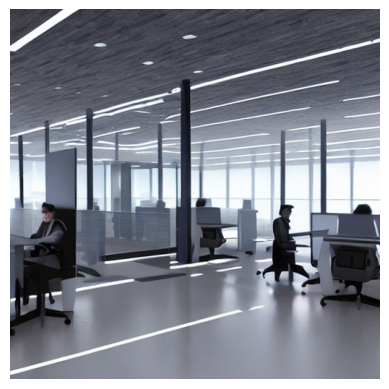

In [ ]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
image.save("generated_image.png")

print("Image saved successfully!")

Image saved successfully!


In [ ]:
!pip install -q pypdf langchain-text-splitters sentence-transformers faiss-cpu

In [ ]:
from google.colab import files
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
uploaded = files.upload()
pdf_name = list(uploaded.keys())[0]

Saving Resume (2).pdf to Resume (2).pdf


In [ ]:
reader = PdfReader(pdf_name)

text = ""

for page in reader.pages:
    text += page.extract_text()

print(text[:1000])

P. Indhu
Phone: 8977563875
Email: indhuponnaganti@gmail.com
GitHub: github.com/indhuponnaganti
LinkedIn: linkedin.com/in/indhu-ponnaganti-273240349
Career Objective
Final-year AI Data Science B.Tech student.enthusiastic about converting complicated datasets into useful business
insights. As a new hire, I’m looking for an entry-level position where I can put my technical knowledge to use,
obtain practical experience, and support the expansion of the company while always learning and developing my
abilities.
Education
P ACE Institute of T echnology Science
B.Tech in Artificial Intelligence and Data Science 2023 – 2027
CGPA: 8.82
Technical Skills
•Programming: Python, C, SQL, Python for data sciences
Projects
Emotion Detection from T ext using NLP & T ransformer Models
•https://github.com/indhuponnaganti/emotion-detection-ml
•Developed an end-to-end multi-class emotion classification system using DistilBERT and traditional NLP
techniques.
•Integrated model with Telegram Bot for real-time 

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

chunks = text_splitter.split_text(text)

print("Total Chunks:", len(chunks))

Total Chunks: 3


In [ ]:
question = input("Ask something about the PDF: ")

Ask something about the PDF: what is the name


In [ ]:
context = "\n\n".join(chunks[:3])

prompt = f"""
You are an expert Social Media Manager.

Using ONLY the information below:

{context}

Answer:

{question}
"""

response = llm.invoke(prompt)

print(response.content)

The name is P. Indhu.


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = embedding_model.encode(chunks)

print("Total Embeddings:", len(embeddings))

Total Embeddings: 3


In [ ]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings))

In [ ]:
question = input("Ask your question: ")

Ask your question: Create a LinkedIn post from this PDF


In [ ]:
question_embedding = embedding_model.encode([question])

distance, indices = index.search(
    np.array(question_embedding),
    k=3
)

In [ ]:
context = ""

for i in indices[0]:
    context += chunks[i] + "\n\n"

print(context)

P. Indhu
Phone: 8977563875
Email: indhuponnaganti@gmail.com
GitHub: github.com/indhuponnaganti
LinkedIn: linkedin.com/in/indhu-ponnaganti-273240349
Career Objective
Final-year AI Data Science B.Tech student.enthusiastic about converting complicated datasets into useful business
insights. As a new hire, I’m looking for an entry-level position where I can put my technical knowledge to use,
obtain practical experience, and support the expansion of the company while always learning and developing my

techniques.
•Integrated model with Telegram Bot for real-time emotion prediction.
•Technologies Used: Python, Transformers, PyTorch, NLP
Internships
I have completed a internship which is done at our collage after 2-2 semester which is conducted by code tantra.
Certifications
Internet of things certification by NPTEL .
1

abilities.
Education
P ACE Institute of T echnology Science
B.Tech in Artificial Intelligence and Data Science 2023 – 2027
CGPA: 8.82
Technical Skills
•Programming: Python, C

In [ ]:
prompt = f"""
You are an expert Social Media Manager.

Using ONLY the information below:

{context}

Question:
{question}
"""

response = llm.invoke(prompt)

print(response.content)

Here's a potential LinkedIn post based on the provided information:

**Excited to Kickstart My Career in AI and Data Science!**

As a final-year student pursuing B.Tech in Artificial Intelligence and Data Science, I'm eager to apply my technical skills and knowledge to drive business growth and innovation. With a strong academic record (CGPA: 8.82) and a passion for converting complex datasets into actionable insights, I'm confident in my ability to make a meaningful impact.

**Key Highlights:**

* Developed an end-to-end emotion detection system using NLP and Transformer Models (check out my project on GitHub: https://github.com/indhuponnaganti/emotion-detection-ml)
* Integrated a Telegram Bot for real-time emotion prediction using Python, Transformers, and PyTorch
* Completed an internship with Code Tantra and certified in Internet of Things by NPTEL

**I'm looking for an entry-level opportunity where I can:**

* Apply my technical skills in Python, C, SQL, and Data Science
* Collabo

In [ ]:
!pip install -q qdrant-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 9.8 MB/s eta 0:00:00


In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

In [ ]:
client = QdrantClient(":memory:")

In [ ]:
client.create_collection(
    collection_name="social_media_docs",
    vectors_config=VectorParams(
        size=embeddings.shape[1],
        distance=Distance.COSINE
    )
)

True

In [ ]:
points = []

for i, embedding in enumerate(embeddings):
    points.append(
        PointStruct(
            id=i,
            vector=embedding.tolist(),
            payload={
                "text": chunks[i]
            }
        )
    )

client.upsert(
    collection_name="social_media_docs",
    points=points
)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

In [ ]:
question = input("Ask a question about the PDF: ")

Ask a question about the PDF: what is the pdf about


In [ ]:
query_vector = embedding_model.encode(question).tolist()

results = client.query_points(
    collection_name="social_media_docs",
    query=query_vector,
    limit=3
)

In [ ]:
context = ""

for point in results.points:
    context += point.payload["text"] + "\n\n"

print(context)

P. Indhu
Phone: 8977563875
Email: indhuponnaganti@gmail.com
GitHub: github.com/indhuponnaganti
LinkedIn: linkedin.com/in/indhu-ponnaganti-273240349
Career Objective
Final-year AI Data Science B.Tech student.enthusiastic about converting complicated datasets into useful business
insights. As a new hire, I’m looking for an entry-level position where I can put my technical knowledge to use,
obtain practical experience, and support the expansion of the company while always learning and developing my

techniques.
•Integrated model with Telegram Bot for real-time emotion prediction.
•Technologies Used: Python, Transformers, PyTorch, NLP
Internships
I have completed a internship which is done at our collage after 2-2 semester which is conducted by code tantra.
Certifications
Internet of things certification by NPTEL .
1

abilities.
Education
P ACE Institute of T echnology Science
B.Tech in Artificial Intelligence and Data Science 2023 – 2027
CGPA: 8.82
Technical Skills
•Programming: Python, C

In [ ]:
prompt = f"""
You are an expert Social Media Manager.

Use ONLY the information below.

{context}

Question:
{question}
"""

response = llm.invoke(prompt)

print(response.content)

The PDF appears to be a resume or a curriculum vitae of P. Indhu, a final-year AI Data Science B.Tech student. It highlights her education, technical skills, projects, internships, and certifications, showcasing her expertise and experience in areas like Python, NLP, and data science.


In [ ]:
print("=" * 50)
print("🤖 AI SOCIAL MEDIA MANAGER")
print("=" * 50)

print("1. Generate Social Media Post")
print("2. Rewrite Existing Post")
print("3. Generate Post from Image")
print("4. Generate Post from PDF (RAG)")
print("5. Exit")

choice = input("\nEnter your choice (1-5): ")

🤖 AI SOCIAL MEDIA MANAGER
1. Generate Social Media Post
2. Rewrite Existing Post
3. Generate Post from Image
4. Generate Post from PDF (RAG)
5. Exit

Enter your choice (1-5): 1


In [ ]:
print("=" * 50)
print("🤖 AI SOCIAL MEDIA MANAGER")
print("=" * 50)

print("1. Generate Social Media Post")
print("2. Rewrite Existing Post")
print("3. Generate Post from Image")
print("4. Generate Post from PDF (RAG)")
print("5. Exit")

choice = input("\nEnter your choice (1-5): ")

if choice == "1":

    platform = input("Choose Platform (LinkedIn / Instagram / Twitter): ")
    topic = input("Enter Topic: ")

    result = generate_platform_post(topic, platform)

    print("\n========== GENERATED POST ==========\n")
    print("📌 Title:", result.title)
    print("\n📝 Post:\n", result.post)
    print("\n🏷️ Hashtags:", ", ".join(result.hashtags))
    print("\n📢 CTA:", result.cta)

elif choice == "2":

    post = input("Paste your existing post:\n")
    feedback = input("How should I improve it?\n")

    prompt = f"""
Rewrite the following social media post.

Post:
{post}

Feedback:
{feedback}

Return JSON format with:
title, post, hashtags, cta
"""

    structured_llm = llm.with_structured_output(SocialMediaPost)
    result = structured_llm.invoke(prompt)

    print("\n========== REWRITTEN POST ==========\n")
    print("📌 Title:", result.title)
    print("\n📝 Post:\n", result.post)
    print("\n🏷️ Hashtags:", ", ".join(result.hashtags))
    print("\n📢 CTA:", result.cta)

elif choice == "3":
    print("Image feature")

elif choice == "4":
    print("PDF Chat Feature")

elif choice == "5":
    print("Thank you!")

else:
    print("Invalid Choice")

🤖 AI SOCIAL MEDIA MANAGER
1. Generate Social Media Post
2. Rewrite Existing Post
3. Generate Post from Image
4. Generate Post from PDF (RAG)
5. Exit

Enter your choice (1-5): 4
PDF Chat Feature


In [ ]:
print("=" * 60)
print("🤖 AI SOCIAL MEDIA MANAGER")
print("Powered by Groq Llama 3.3 + LangGraph + RAG")
print("=" * 60)

🤖 AI SOCIAL MEDIA MANAGER
Powered by Groq Llama 3.3 + LangGraph + RAG
